In [113]:
import numpy as np 
import matplotlib.pyplot as plt
from read_gaukuk import ReadGaukuk
DEN = 0 
MTX = 1 
MTY = 2 
MTZ = 3 
ENG = 4 

In [159]:
frameID = 1
filename = "../bin/cons_" + str(frameID).zfill(5)
frame = ReadGaukuk(filename)
ib = frame.nGhost 
ie = frame.nGhost+frame.nx 

print(frame.cons.shape)
print(frame.nGhost)

dx = frame.xc[1] - frame.xc[0]
xlist = np.linspace(frame.xc[0]-dx, frame.xc[-1]+dx, frame.lenx)
# print(frame.cons[DEN,1,1,:])

(5, 3, 3, 514)
1


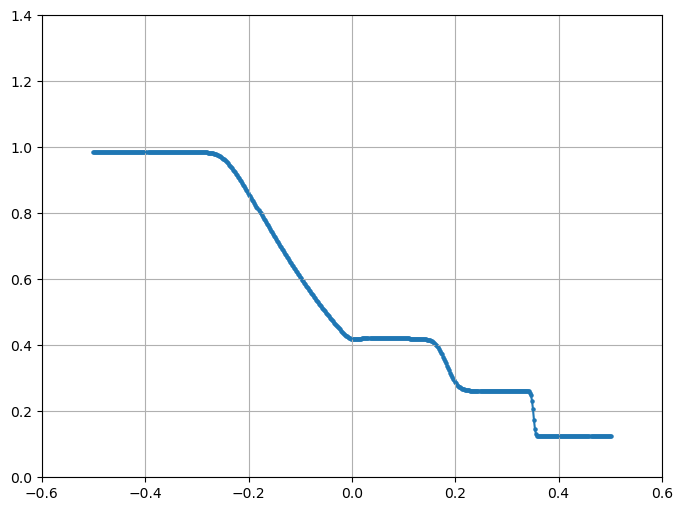

In [172]:
frameID = 20
filename = "../bin/cons_" + str(frameID).zfill(5)
frame = ReadGaukuk(filename)
ID = DEN 
k = 8
j = 8
fig = plt.figure(figsize=(8,6))
ax = plt.subplot(111)
ax.plot(xlist, frame.cons[ID,k,j,:])
ax.scatter(xlist, frame.cons[ID,k,j,:], s = 5)
ax.set_xlim(-0.6, 0.6)
ax.set_ylim(0, 1.4)
plt.grid()
plt.show()

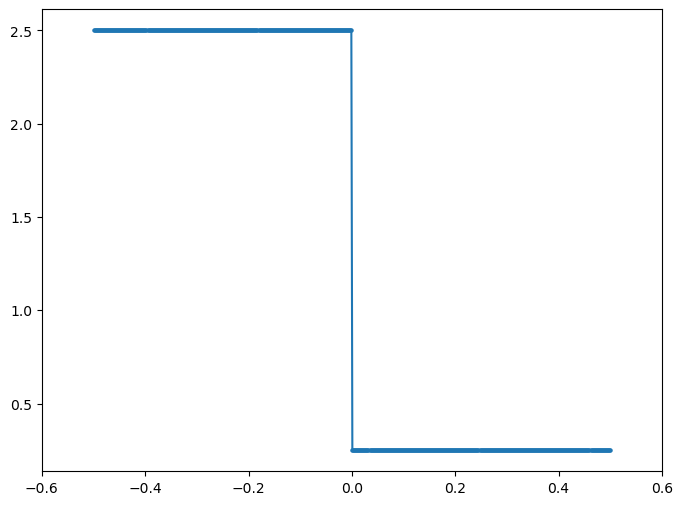

In [148]:
ID = ENG 
fig = plt.figure(figsize=(8,6))
ax = plt.subplot(111)
ax.plot(frame.xc, frame.cons[ID,k,j,ib:ie])
ax.scatter(frame.xc, frame.cons[ID,k,j,ib:ie], s = 5)
ax.set_xlim(-0.6, 0.6)
plt.show()

In [99]:
denl = 1
denr = 1
prel = 1
prer = 1
vxl = 0 
vyr = 0 
vyl = 0 
vxr = 0 
vzl = 0 
vzr = 0 
gamma = 1.4 
al = np.sqrt(gamma*prel/denl)
ar = np.sqrt(gamma*prer/denr)
prePVRS = 0.5*(prel + prer) - 0.125*(vxr - vxl)*(denl + denr)*(al + ar)

print(al, ar)
print("prePVRS: ", prePVRS)

gmRec = 1/gamma
temp = prePVRS/prel-1
ql = np.sqrt( 1 + 0.5*(1 + gmRec) * temp )
temp = prePVRS/prer-1
qr = np.sqrt( 1 + 0.5*(1 + gmRec) * temp ) 
print("ql, qr: ", ql, qr)

sl = vxl - al*ql; 
sr = vxr + ar*qr; 
ss = ( prer - prel + denl*vxl*(sl-vxl) - denr*vxr*(sr-vxr) ) / ( denl*(sl-vxl) - denr*(sr-vxr) ) 
print("sl, sr", sl, sr)
print("ss: ", ss)

1.1832159566199232 1.1832159566199232
prePVRS:  1.0
ql, qr:  1.0 1.0
sl, sr -1.1832159566199232 1.1832159566199232
ss:  -0.0


In [104]:
gm1Rec = 1.0 / (gamma - 1.0)
el = prel*gm1Rec + 0.5*denl*(vxl*vxl+vyl*vyl+vzl*vzl)
er = prer*gm1Rec + 0.5*denr*(vxr*vxr+vyr*vyr+vzr*vzr)

cl = min(0.0, sl)*(ss-vxl)/(sl-ss)
cr = max(0.0, sr)*(ss-vxr)/(sr-ss)
if (ss>=0):
    selectl = 1.0 
else:
    selectl = 0
selectr = 1.0 - selectl

fl1 = denl * (vxl + cl) 
fl2 = denl * (vxl*vxl + cl*sl) + prel
fl3 = fl1*vyl                            
fl4 = fl1*vzl                             
fl5 = (el + prel)*(vxl + cl) + denl*cl*ss*(sl-vxl)

fr1 = denr * (vxr + cr)
fr2 = denr * (vxr*vxr + cr*sr) + prer
fr3 = fr1*vyr                        
fr4 = fr1*vzr                         
fr5 = (er + prer)*(vxr + cr) + denr*cr*ss*(sr-vxr)

print(fl1)
print(fl2)
print(fl3)
print(fl4)
print(fl5)
print()
print(fr1)
print(fr2)
print(fr3)
print(fr4)
print(fr5)

0.0
1.0
0.0
0.0
0.0

0.0
1.0
0.0
0.0
0.0
